# Paired TCREmp on VDJdb Full

This notebook analyzes paired TRA/TRB embeddings from `vdjdb_full.txt.gz` in two modes:

1. Strict paired rows already containing both chains.
2. The same human VDJdb rows after single-chain records are repaired with missing-chain imputation.

The paired embedding is a direct concatenation of chain-specific TCREmp embeddings.

In [1]:
# Configure imports, plotting, randomness, and print environment versions.
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import sklearn
import umap
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, normalize as l2normalize

try:
    import kneed
    from kneed import KneeLocator
except ImportError:
    kneed = None
    KneeLocator = None

from mir.common.parser import VDJdbFullPairedParser
from mir.common.single_cell import build_tenx_sample_from_cell_clonotypes
from mir.common.single_cell_repair import impute_missing_chains
from mir.embedding.tcremp import PairedTCREmp
from mir.utils.notebook_assets import ensure_airr_benchmark, find_airr_benchmark_vdjdb_full, find_repo_root

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='talk')

print(f'Python: {sys.version.split()[0]}')
print(f'numpy: {np.__version__}')
print(f'polars: {pl.__version__}')
print(f'scikit-learn: {sklearn.__version__}')
print(f'umap-learn: {umap.__version__}')
print(f'kneed: {getattr(kneed, "__version__", "not-installed")}')

/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.12
numpy: 2.4.4
polars: 1.39.3
scikit-learn: 1.8.0
umap-learn: 0.5.12
kneed: 0.8.6


In [2]:
# Load VDJdb full rows, build strict/imputed paired datasets, and show metadata access patterns.
repo_root = find_repo_root(Path.cwd())
dataset_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=['vdjdb/**'])
vdjdb_full = find_airr_benchmark_vdjdb_full(dataset_root)
parser = VDJdbFullPairedParser()

t0 = time.perf_counter()
strict_cell_df, strict_metadata = parser.parse_cell_clonotypes_file(
    vdjdb_full,
    sample_id='vdjdb_full_human_strict',
    species='HomoSapiens',
    include_incomplete=False,
)
strict_sample = build_tenx_sample_from_cell_clonotypes(
    strict_cell_df,
    sample_id='vdjdb_full_human_strict',
    barcode_metadata=strict_metadata,
)
strict_runtime = time.perf_counter() - t0

t0 = time.perf_counter()
impute_input_df, impute_metadata = parser.parse_cell_clonotypes_file(
    vdjdb_full,
    sample_id='vdjdb_full_human_impute',
    species='HomoSapiens',
    include_incomplete=True,
)
imputed_cell_df = impute_missing_chains(impute_input_df)
imputed_sample = build_tenx_sample_from_cell_clonotypes(
    imputed_cell_df,
    sample_id='vdjdb_full_human_impute',
    barcode_metadata=impute_metadata,
)
imputed_runtime = time.perf_counter() - t0

strict_pairs = strict_sample.paired_locus_repertoires['TRA_TRB'].paired_clonotypes
imputed_pairs = imputed_sample.paired_locus_repertoires['TRA_TRB'].paired_clonotypes

print(f'VDJdb full file: {vdjdb_full}')
print(f'Strict rows:   {strict_cell_df.height:,} chains -> {len(strict_pairs):,} paired clonotypes ({strict_runtime:.2f}s)')
print(f'Imputed rows:  {imputed_cell_df.height:,} chains -> {len(imputed_pairs):,} paired clonotypes ({imputed_runtime:.2f}s)')
print(f'Added paired clonotypes after imputation: {len(imputed_pairs) - len(strict_pairs):,}')

# Demonstration 1: direct dictionary access by VDJdb record id (synthetic barcode).
for barcode in ['993', '1007']:
    meta = strict_sample.single_cell_repertoire.barcode_metadata.get(barcode, {})
    print(barcode, {k: meta.get(k, '') for k in ['antigen.epitope', 'antigen.gene', 'antigen.species', 'mhc.a', 'mhc.class']})

# Demonstration 2: tabular metadata access for joins/filters.
strict_meta_df = strict_sample.single_cell_repertoire.metadata_to_polars()
print(strict_meta_df.select(['barcode', 'vdjdb_record_id', 'antigen.epitope', 'mhc.a']).head(5))

Fetching 3 files: 100%|██████████| 3/3 [00:00<00:00, 836.41it/s]


VDJdb full file: /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/vdjdb/vdjdb-2025-12-29/vdjdb_full.txt.gz
Strict rows:   160,626 chains -> 80,313 paired clonotypes (2.44s)
Imputed rows:  252,274 chains -> 126,137 paired clonotypes (152.59s)
Added paired clonotypes after imputation: 45,824
993 {'antigen.epitope': 'HPNGYKSLSTL', 'antigen.gene': 'NS1', 'antigen.species': 'InfluenzaB', 'mhc.a': 'HLA-B*07:02', 'mhc.class': 'MHCI'}
1007 {'antigen.epitope': 'RPIIRPATL', 'antigen.gene': 'NP', 'antigen.species': 'InfluenzaB', 'mhc.a': 'HLA-B*07:02', 'mhc.class': 'MHCI'}
shape: (5, 4)
┌─────────┬─────────────────┬─────────────────┬─────────────┐
│ barcode ┆ vdjdb_record_id ┆ antigen.epitope ┆ mhc.a       │
│ ---     ┆ ---             ┆ ---             ┆ ---         │
│ str     ┆ str             ┆ str             ┆ str         │
╞═════════╪═════════════════╪═════════════════╪═════════════╡
│ 10000   ┆ 10000           ┆ GILGFVFTL       ┆ HLA-A*02:01 │
│ 100000  ┆ 100000          ┆ NL

In [3]:
# Convert paired repertoires to polars tables and build balanced strict/imputed subsets.
def paired_sample_to_table(sample):
    rows = []
    for pair in sample.paired_locus_repertoires['TRA_TRB'].paired_clonotypes:
        chains = {pair.clonotype1.locus: pair.clonotype1, pair.clonotype2.locus: pair.clonotype2}
        barcode = pair.pair_id.split('_', 1)[0]
        meta = sample.single_cell_repertoire.barcode_metadata.get(barcode, {})
        rows.append(
            {
                'pair_id': pair.pair_id,
                'barcode': barcode,
                'epitope': meta.get('antigen.epitope', ''),
                'antigen_gene': meta.get('antigen.gene', ''),
                'antigen_species': meta.get('antigen.species', ''),
                'mhc_a': meta.get('mhc.a', ''),
                'tra_v': chains['TRA'].v_gene,
                'tra_j': chains['TRA'].j_gene,
                'tra_cdr3': chains['TRA'].junction_aa,
                'trb_v': chains['TRB'].v_gene,
                'trb_j': chains['TRB'].j_gene,
                'trb_cdr3': chains['TRB'].junction_aa,
                'tra_len': len(chains['TRA'].junction_aa),
                'trb_len': len(chains['TRB'].junction_aa),
                'paired_cdr3_len': len(chains['TRA'].junction_aa) + len(chains['TRB'].junction_aa),
            }
        )
    return pl.DataFrame(rows)


def add_epitope_category(df, focal_epitopes):
    return df.with_columns(
        pl.when(pl.col('epitope').is_in(focal_epitopes))
        .then(pl.col('epitope'))
        .otherwise(pl.lit('other'))
        .alias('epitope_cat')
    )


def seeded_sample(df, n):
    if df.height <= n:
        return df
    return df.sample(n=n, with_replacement=False, shuffle=True, seed=SEED)


def select_balanced(df, focal_epitopes, sample_per_epitope=250, other_sample=500):
    parts = []
    for ep in focal_epitopes:
        parts.append(seeded_sample(df.filter(pl.col('epitope_cat') == ep), sample_per_epitope))
    parts.append(seeded_sample(df.filter(pl.col('epitope_cat') == 'other'), other_sample))
    return pl.concat([x for x in parts if x.height > 0], how='vertical')

strict_df = paired_sample_to_table(strict_sample)
imputed_df = paired_sample_to_table(imputed_sample)

FOCAL_EPITOPES = (
    strict_df.group_by('epitope')
    .len()
    .sort('len', descending=True)
    .head(10)
    .get_column('epitope')
    .to_list()
)
SAMPLE_PER_EPITOPE = 250
OTHER_SAMPLE = 500

strict_df = add_epitope_category(strict_df, FOCAL_EPITOPES)
imputed_df = add_epitope_category(imputed_df, FOCAL_EPITOPES)

strict_sel = select_balanced(strict_df, FOCAL_EPITOPES, SAMPLE_PER_EPITOPE, OTHER_SAMPLE)
imputed_sel = select_balanced(imputed_df, FOCAL_EPITOPES, SAMPLE_PER_EPITOPE, OTHER_SAMPLE)

print('Focal epitopes:', FOCAL_EPITOPES)
print('Strict subset size:', strict_sel.height)
print(strict_sel.group_by('epitope_cat').len().sort('len', descending=True))
print()
print('Imputed subset size:', imputed_sel.height)
print(imputed_sel.group_by('epitope_cat').len().sort('len', descending=True))

Focal epitopes: ['SLLMWITQV', 'KLGGALQAK', 'NLVPMVATV', 'GILGFVFTL', 'RAKFKQLL', 'AVFDRKSDAK', 'GLCTLVAML', 'IVTDFSVIK', 'FLRGRAYGL', 'LLAGIGTVPI']
Strict subset size: 3000
shape: (11, 2)
┌─────────────┬─────┐
│ epitope_cat ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ other       ┆ 500 │
│ LLAGIGTVPI  ┆ 250 │
│ NLVPMVATV   ┆ 250 │
│ SLLMWITQV   ┆ 250 │
│ GLCTLVAML   ┆ 250 │
│ …           ┆ …   │
│ GILGFVFTL   ┆ 250 │
│ KLGGALQAK   ┆ 250 │
│ RAKFKQLL    ┆ 250 │
│ AVFDRKSDAK  ┆ 250 │
│ IVTDFSVIK   ┆ 250 │
└─────────────┴─────┘

Imputed subset size: 3000
shape: (11, 2)
┌─────────────┬─────┐
│ epitope_cat ┆ len │
│ ---         ┆ --- │
│ str         ┆ u32 │
╞═════════════╪═════╡
│ other       ┆ 500 │
│ GLCTLVAML   ┆ 250 │
│ SLLMWITQV   ┆ 250 │
│ RAKFKQLL    ┆ 250 │
│ LLAGIGTVPI  ┆ 250 │
│ …           ┆ …   │
│ IVTDFSVIK   ┆ 250 │
│ FLRGRAYGL   ┆ 250 │
│ NLVPMVATV   ┆ 250 │
│ GILGFVFTL   ┆ 250 │
│ AVFDRKSDAK  ┆ 250 │
└─────────────┴─────┘


In [4]:
# Embed balanced paired subsets and report per-record throughput (paired vs single-chain sum).
strict_pair_map = {pair.pair_id: pair for pair in strict_pairs}
imputed_pair_map = {pair.pair_id: pair for pair in imputed_pairs}

strict_selected_pairs = [strict_pair_map[pair_id] for pair_id in strict_sel.get_column('pair_id').to_list()]
imputed_selected_pairs = [imputed_pair_map[pair_id] for pair_id in imputed_sel.get_column('pair_id').to_list()]

N_PROTO = 500
model = PairedTCREmp.from_defaults(species='human', locus_pair='TRA_TRB', n_prototypes=N_PROTO, junction_method='fixed_gap')

t0 = time.perf_counter()
X_strict_raw = model.embed(strict_selected_pairs)
t_strict_embed = time.perf_counter() - t0

t0 = time.perf_counter()
X_imputed_raw = model.embed(imputed_selected_pairs)
t_imputed_embed = time.perf_counter() - t0

tra_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRA' else pair.clonotype2 for pair in strict_selected_pairs]
trb_only = [pair.clonotype1 if pair.clonotype1.locus == 'TRB' else pair.clonotype2 for pair in strict_selected_pairs]

t0 = time.perf_counter()
X_tra_only = model.chain1_model.embed(tra_only)
t_tra = time.perf_counter() - t0

t0 = time.perf_counter()
X_trb_only = model.chain2_model.embed(trb_only)
t_trb = time.perf_counter() - t0

print(f'Strict paired embedding:  {X_strict_raw.shape}  {t_strict_embed:.3f}s  ({1e3 * t_strict_embed / len(strict_selected_pairs):.3f} ms/record)')
print(f'Imputed paired embedding: {X_imputed_raw.shape}  {t_imputed_embed:.3f}s  ({1e3 * t_imputed_embed / len(imputed_selected_pairs):.3f} ms/record)')
print(f'Strict TRA only: {t_tra:.3f}s  Strict TRB only: {t_trb:.3f}s  Paired/(TRA+TRB): {t_strict_embed / max(t_tra + t_trb, 1e-9):.3f}x')

Strict paired embedding:  (3000, 3000)  0.091s  (0.030 ms/record)
Imputed paired embedding: (3000, 3000)  0.088s  (0.029 ms/record)
Strict TRA only: 0.040s  Strict TRB only: 0.042s  Paired/(TRA+TRB): 1.103x


In [ ]:
# Compute PCA variance, kneedle eps, clustering metrics, and chain-level variants.
def select_eps_kneedle(X_pca, k=4):
    nn = NearestNeighbors(n_neighbors=k, metric='euclidean')
    nn.fit(X_pca)
    dists, _ = nn.kneighbors(X_pca)
    kth = np.sort(dists[:, -1])
    eps_floor = float(np.quantile(kth, 0.10))
    eps_cap = float(np.quantile(kth, 0.40))
    if KneeLocator is None:
        return kth, eps_floor, None
    knee = KneeLocator(
        np.arange(len(kth)),
        kth,
        curve='convex',
        direction='increasing',
        interp_method='polynomial',
    )
    if knee.knee is None:
        return kth, eps_floor, None
    eps = min(float(kth[knee.knee]), eps_cap)
    return kth, max(eps, eps_floor), int(knee.knee)


def analyze_embedding(X_raw, labels):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    pca_full = PCA(random_state=SEED).fit(X_scaled)
    cum = np.cumsum(pca_full.explained_variance_ratio_)
    n_comp = int(np.searchsorted(cum, 0.90)) + 1
    pca = PCA(n_components=n_comp, random_state=SEED)
    X_pca = l2normalize(pca.fit_transform(X_scaled))
    kth, eps, knee_idx = select_eps_kneedle(X_pca)
    clusters = DBSCAN(eps=eps, min_samples=3, metric='euclidean', n_jobs=-1).fit_predict(X_pca)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        X_umap = umap.UMAP(
            n_components=2,
            n_neighbors=30,
            min_dist=0.10,
            metric='euclidean',
            random_state=SEED,
        ).fit_transform(X_pca)

    mask = clusters != -1
    cluster_ids = np.unique(clusters[mask])
    per_cluster_purity = []
    for cid in cluster_ids:
        cl_labels = labels[clusters == cid]
        uniq, counts = np.unique(cl_labels, return_counts=True)
        per_cluster_purity.append(float(counts.max() / counts.sum()))

    purity = float(np.mean(per_cluster_purity)) if per_cluster_purity else 0.0
    consistency = float(np.mean(np.array(per_cluster_purity) >= 0.70)) if per_cluster_purity else 0.0

    return {
        'X_pca': X_pca,
        'X_umap': X_umap,
        'cum': cum,
        'explained': pca_full.explained_variance_ratio_,
        'n_comp': n_comp,
        'kth': kth,
        'knee_idx': knee_idx,
        'eps': eps,
        'clusters': clusters,
        'retention': float(mask.mean()),
        'purity': purity,
        'consistency': consistency,
        'median_4nn': float(np.median(kth)),
        'n_clusters': int(len(cluster_ids)),
    }


strict_labels = strict_sel.get_column('epitope_cat').to_numpy()
imputed_labels = imputed_sel.get_column('epitope_cat').to_numpy()

strict_analysis = analyze_embedding(X_strict_raw, strict_labels)
imputed_analysis = analyze_embedding(X_imputed_raw, imputed_labels)

# Chain-only analyses on strict paired records to identify which chain drives SLL behavior.
strict_tra_analysis = analyze_embedding(X_tra_only, strict_labels)
strict_trb_analysis = analyze_embedding(X_trb_only, strict_labels)

summary_df = pl.DataFrame(
    [
        {
            'mode': 'strict-paired',
            'n_pairs': len(strict_selected_pairs),
            'pcs_90pct': strict_analysis['n_comp'],
            'eps': strict_analysis['eps'],
            'clusters': strict_analysis['n_clusters'],
            'retention': strict_analysis['retention'],
            'purity': strict_analysis['purity'],
            'consistency_70': strict_analysis['consistency'],
            'median_4nn': strict_analysis['median_4nn'],
        },
        {
            'mode': 'imputed-paired',
            'n_pairs': len(imputed_selected_pairs),
            'pcs_90pct': imputed_analysis['n_comp'],
            'eps': imputed_analysis['eps'],
            'clusters': imputed_analysis['n_clusters'],
            'retention': imputed_analysis['retention'],
            'purity': imputed_analysis['purity'],
            'consistency_70': imputed_analysis['consistency'],
            'median_4nn': imputed_analysis['median_4nn'],
        },
        {
            'mode': 'strict-TRA-only',
            'n_pairs': len(strict_selected_pairs),
            'pcs_90pct': strict_tra_analysis['n_comp'],
            'eps': strict_tra_analysis['eps'],
            'clusters': strict_tra_analysis['n_clusters'],
            'retention': strict_tra_analysis['retention'],
            'purity': strict_tra_analysis['purity'],
            'consistency_70': strict_tra_analysis['consistency'],
            'median_4nn': strict_tra_analysis['median_4nn'],
        },
        {
            'mode': 'strict-TRB-only',
            'n_pairs': len(strict_selected_pairs),
            'pcs_90pct': strict_trb_analysis['n_comp'],
            'eps': strict_trb_analysis['eps'],
            'clusters': strict_trb_analysis['n_clusters'],
            'retention': strict_trb_analysis['retention'],
            'purity': strict_trb_analysis['purity'],
            'consistency_70': strict_trb_analysis['consistency'],
            'median_4nn': strict_trb_analysis['median_4nn'],
        },
    ]
)
print(summary_df)

shape: (4, 9)
┌────────────┬─────────┬───────────┬───────────┬───┬───────────┬──────────┬────────────┬───────────┐
│ mode       ┆ n_pairs ┆ pcs_90pct ┆ eps       ┆ … ┆ retention ┆ purity   ┆ consistenc ┆ median_4n │
│ ---        ┆ ---     ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---      ┆ y_70       ┆ n         │
│ str        ┆ i64     ┆ i64       ┆ f64       ┆   ┆ f64       ┆ f64      ┆ ---        ┆ ---       │
│            ┆         ┆           ┆           ┆   ┆           ┆          ┆ f64        ┆ f64       │
╞════════════╪═════════╪═══════════╪═══════════╪═══╪═══════════╪══════════╪════════════╪═══════════╡
│ strict-pai ┆ 3000    ┆ 59        ┆ 0.272472  ┆ … ┆ 0.265333  ┆ 0.965217 ┆ 0.934783   ┆ 0.723607  │
│ red        ┆         ┆           ┆           ┆   ┆           ┆          ┆            ┆           │
│ imputed-pa ┆ 3000    ┆ 60        ┆ 0.647444  ┆ … ┆ 0.428     ┆ 0.573564 ┆ 0.259259   ┆ 0.74283   │
│ ired       ┆         ┆           ┆           ┆   ┆           ┆          ┆  

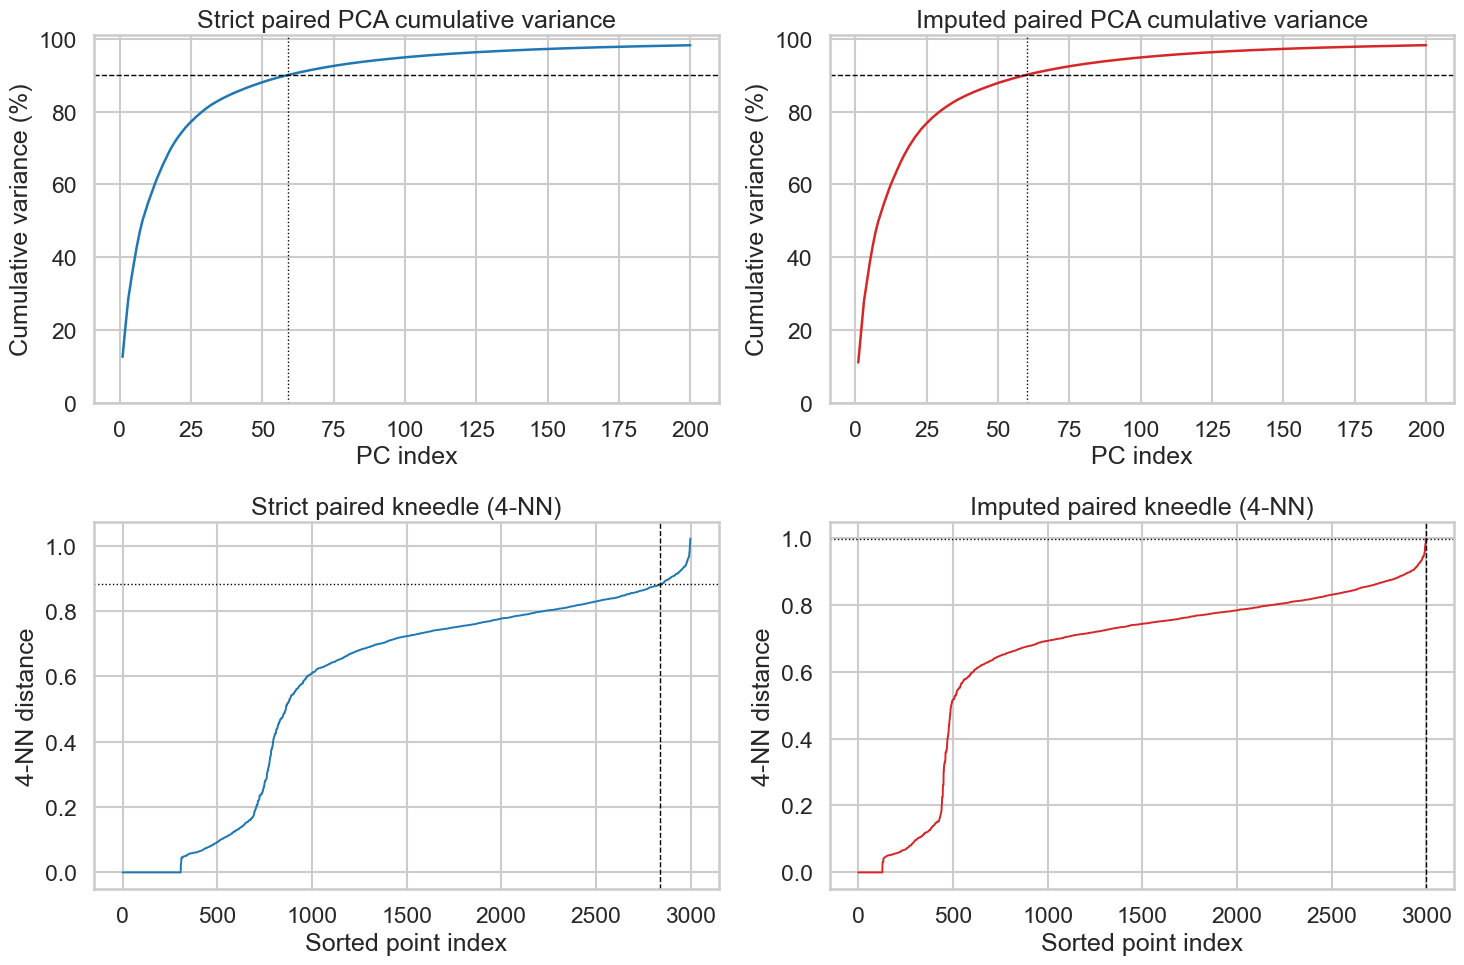

Strict paired:  eps=0.8821, PCs@90%=59, clusters=2, retention=0.991, purity=0.584, consistency=0.500
Imputed paired: eps=0.9979, PCs@90%=60, clusters=1, retention=1.000, purity=0.167, consistency=0.000


In [6]:
# Plot PCA variance explained and kneedle curves for strict vs imputed paired embeddings.
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, analysis, title, color in [
    (axes[0, 0], strict_analysis, 'Strict paired', '#1f77b4'),
    (axes[0, 1], imputed_analysis, 'Imputed paired', '#d62728'),
]:
    max_show = min(200, len(analysis['cum']))
    ax.plot(np.arange(1, max_show + 1), analysis['cum'][:max_show] * 100, color=color, lw=1.8)
    ax.axhline(90, color='black', ls='--', lw=1.0)
    ax.axvline(analysis['n_comp'], color='black', ls=':', lw=1.0)
    ax.set_title(f'{title} PCA cumulative variance')
    ax.set_xlabel('PC index')
    ax.set_ylabel('Cumulative variance (%)')
    ax.set_ylim(0, 101)

for ax, analysis, title, color in [
    (axes[1, 0], strict_analysis, 'Strict paired', '#1f77b4'),
    (axes[1, 1], imputed_analysis, 'Imputed paired', '#d62728'),
]:
    ax.plot(analysis['kth'], color=color, lw=1.4)
    if analysis['knee_idx'] is not None:
        ax.axvline(analysis['knee_idx'], color='black', ls='--', lw=1.0)
    ax.axhline(analysis['eps'], color='black', ls=':', lw=1.0)
    ax.set_title(f'{title} kneedle (4-NN)')
    ax.set_xlabel('Sorted point index')
    ax.set_ylabel('4-NN distance')

plt.tight_layout()
plt.show()

print('Strict paired:  eps={:.4f}, PCs@90%={}, clusters={}, retention={:.3f}, purity={:.3f}, consistency={:.3f}'.format(
    strict_analysis['eps'], strict_analysis['n_comp'], strict_analysis['n_clusters'], strict_analysis['retention'], strict_analysis['purity'], strict_analysis['consistency']
))
print('Imputed paired: eps={:.4f}, PCs@90%={}, clusters={}, retention={:.3f}, purity={:.3f}, consistency={:.3f}'.format(
    imputed_analysis['eps'], imputed_analysis['n_comp'], imputed_analysis['n_clusters'], imputed_analysis['retention'], imputed_analysis['purity'], imputed_analysis['consistency']
))

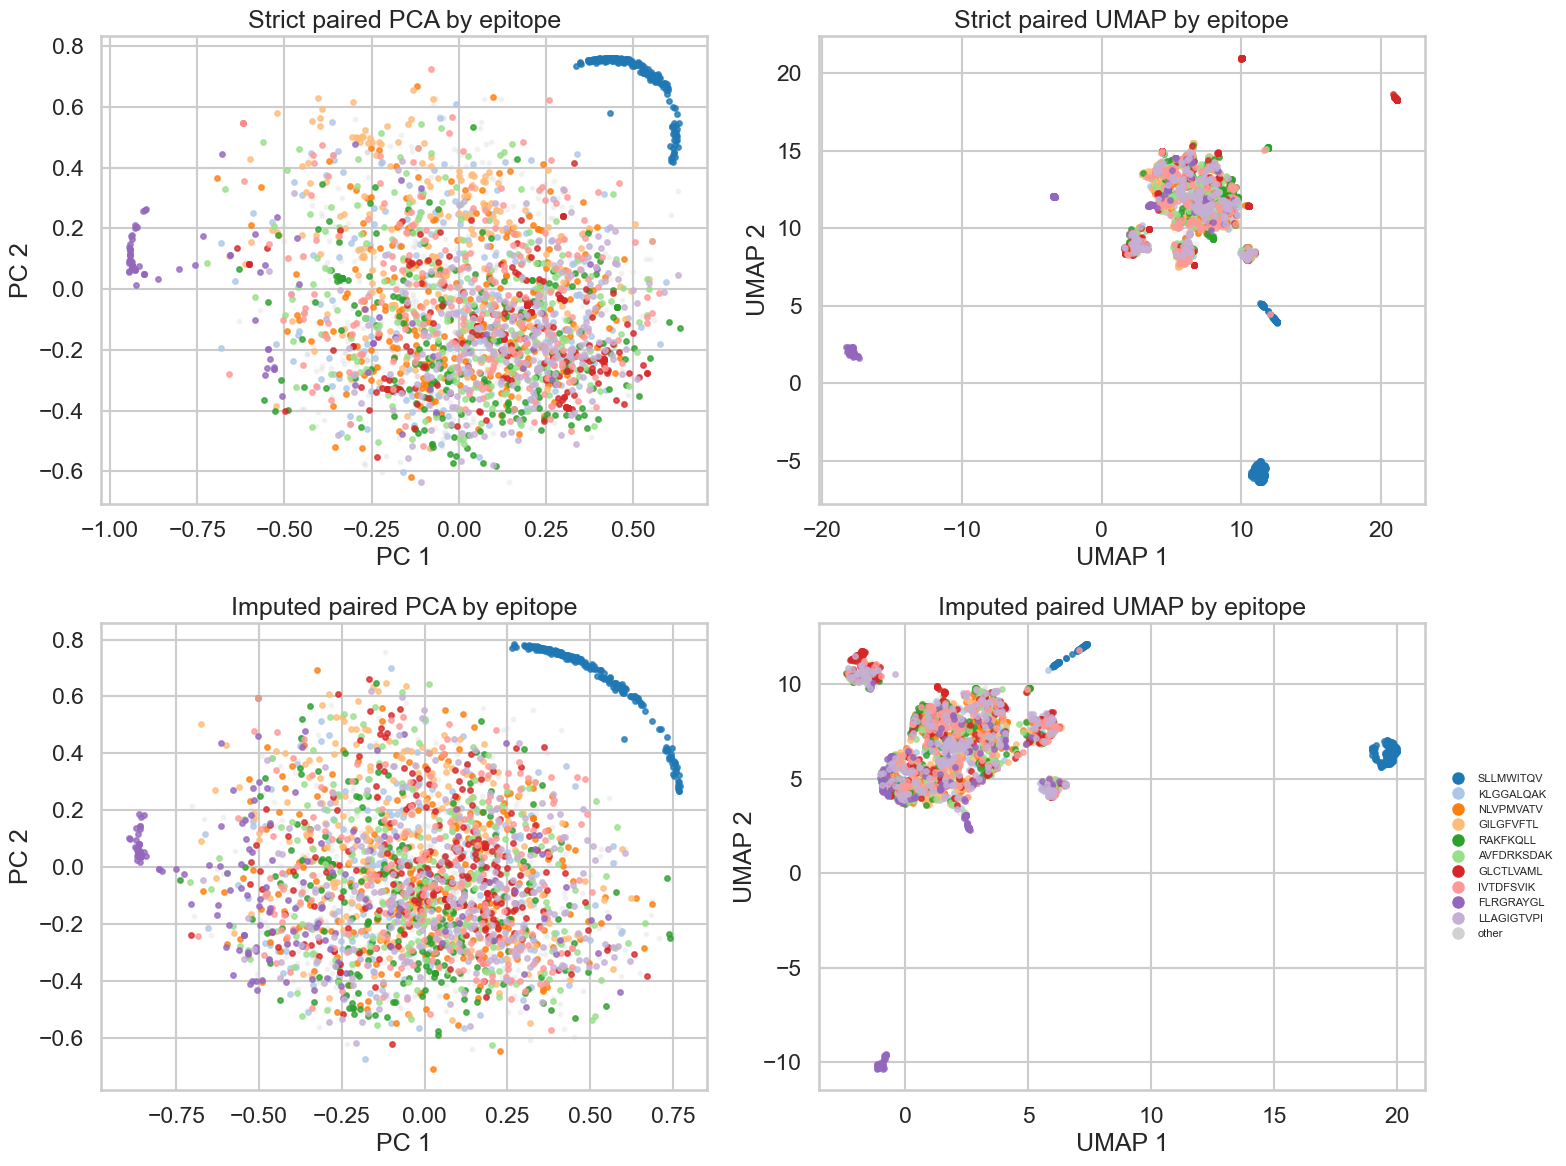

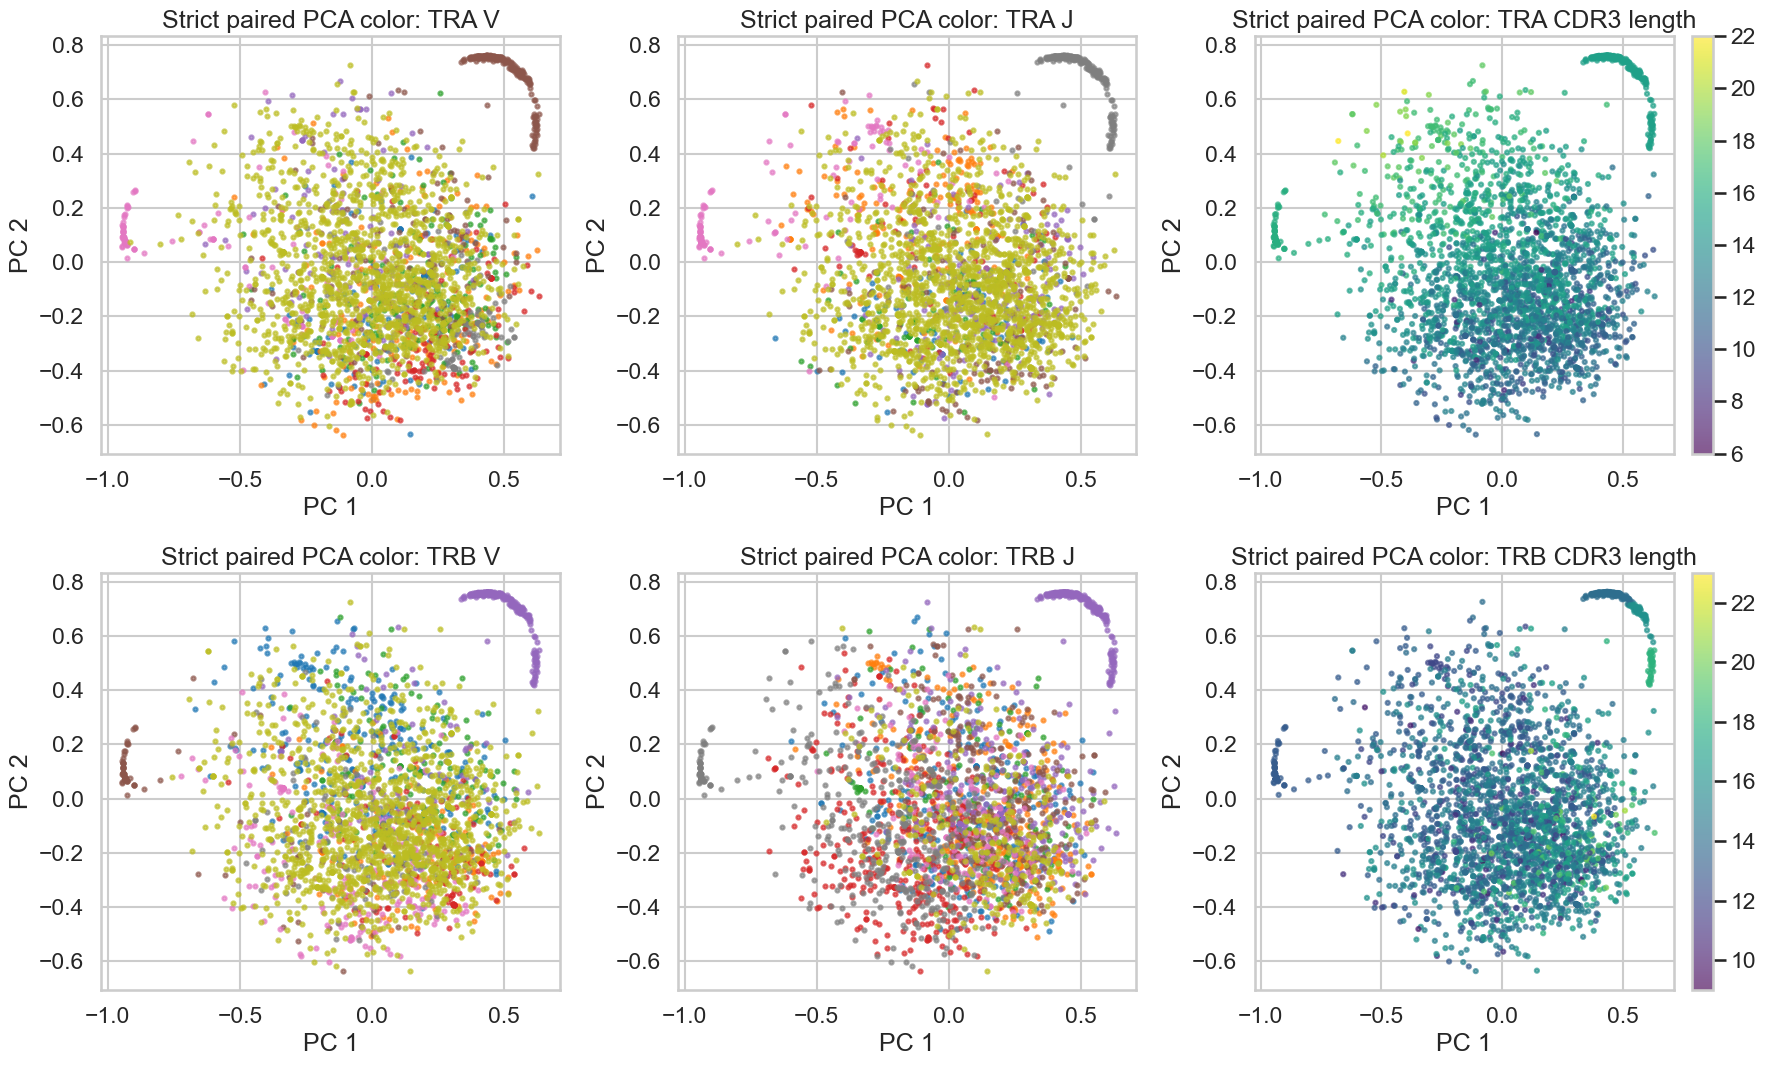

In [7]:
# Visualize paired embeddings by epitope and by chain-level features (length / V / J usage).
palette_keys = FOCAL_EPITOPES + ['other']
palette_values = sns.color_palette('tab20', n_colors=len(FOCAL_EPITOPES)) + [(0.82, 0.82, 0.82)]
PALETTE = dict(zip(palette_keys, palette_values))


def scatter_epitopes(ax, coords, labels, title, xlabel, ylabel):
    labels = np.asarray(labels)
    mask_other = labels == 'other'
    ax.scatter(coords[mask_other, 0], coords[mask_other, 1], s=8, alpha=0.2, color=PALETTE['other'], rasterized=True)
    for epitope in FOCAL_EPITOPES:
        mask = labels == epitope
        if mask.sum() == 0:
            continue
        ax.scatter(coords[mask, 0], coords[mask, 1], s=12, alpha=0.75, color=PALETTE[epitope], rasterized=True, label=epitope)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
scatter_epitopes(axes[0, 0], strict_analysis['X_pca'][:, :2], strict_labels, 'Strict paired PCA by epitope', 'PC 1', 'PC 2')
scatter_epitopes(axes[0, 1], strict_analysis['X_umap'], strict_labels, 'Strict paired UMAP by epitope', 'UMAP 1', 'UMAP 2')
scatter_epitopes(axes[1, 0], imputed_analysis['X_pca'][:, :2], imputed_labels, 'Imputed paired PCA by epitope', 'PC 1', 'PC 2')
scatter_epitopes(axes[1, 1], imputed_analysis['X_umap'], imputed_labels, 'Imputed paired UMAP by epitope', 'UMAP 1', 'UMAP 2')
handles = [plt.Line2D([0], [0], marker='o', linestyle='', markersize=8, color=PALETTE[ep], label=ep) for ep in FOCAL_EPITOPES]
handles.append(plt.Line2D([0], [0], marker='o', linestyle='', markersize=8, color=PALETTE['other'], label='other'))
axes[1, 1].legend(handles=handles, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False, fontsize=8)
plt.tight_layout()
plt.show()


def top_categories(values, top_n=8):
    uniq, counts = np.unique(values, return_counts=True)
    order = np.argsort(-counts)
    top = set(uniq[order[:top_n]])
    return np.array([v if v in top else 'other' for v in values])


strict_tra_v = top_categories(strict_sel.get_column('tra_v').to_numpy())
strict_trb_v = top_categories(strict_sel.get_column('trb_v').to_numpy())
strict_tra_j = top_categories(strict_sel.get_column('tra_j').to_numpy())
strict_trb_j = top_categories(strict_sel.get_column('trb_j').to_numpy())
strict_tra_len = strict_sel.get_column('tra_len').to_numpy()
strict_trb_len = strict_sel.get_column('trb_len').to_numpy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for ax, values, title in [
    (axes[0, 0], strict_tra_v, 'Strict paired PCA color: TRA V'),
    (axes[0, 1], strict_tra_j, 'Strict paired PCA color: TRA J'),
    (axes[0, 2], strict_tra_len, 'Strict paired PCA color: TRA CDR3 length'),
    (axes[1, 0], strict_trb_v, 'Strict paired PCA color: TRB V'),
    (axes[1, 1], strict_trb_j, 'Strict paired PCA color: TRB J'),
    (axes[1, 2], strict_trb_len, 'Strict paired PCA color: TRB CDR3 length'),
]:
    if values.dtype.kind in {'U', 'O'}:
        cats = np.unique(values)
        cmap = sns.color_palette('tab10', n_colors=len(cats))
        for c_idx, cat in enumerate(cats):
            mask = values == cat
            ax.scatter(strict_analysis['X_pca'][mask, 0], strict_analysis['X_pca'][mask, 1], s=9, alpha=0.65, color=cmap[c_idx], rasterized=True, label=cat if c_idx < 8 else None)
    else:
        sc = ax.scatter(strict_analysis['X_pca'][:, 0], strict_analysis['X_pca'][:, 1], c=values, cmap='viridis', s=9, alpha=0.65, rasterized=True)
        plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')

plt.tight_layout()
plt.show()

In [8]:
# Diagnose the SLL outlier and check whether it is a bug or chain-driven biology.
TARGET_EPITOPE = 'SLLMWITQV'


def epitope_distance_profile(coords, labels):
    global_centroid = coords.mean(axis=0)
    rows = []
    for ep in np.unique(labels):
        mask = labels == ep
        ep_coords = coords[mask]
        ep_centroid = ep_coords.mean(axis=0)
        intra = np.linalg.norm(ep_coords - ep_centroid, axis=1)
        inter = np.linalg.norm(ep_coords - global_centroid, axis=1)
        rows.append(
            {
                'epitope': ep,
                'n': int(mask.sum()),
                'mean_intra_dist': float(intra.mean()),
                'mean_global_dist': float(inter.mean()),
            }
        )
    return pl.DataFrame(rows).sort('mean_global_dist', descending=True)


def sll_chain_signal(table, labels, target_epitope):
    target = labels == target_epitope
    non_target = labels != target_epitope
    target_rows = table.filter(pl.Series(target))
    non_target_rows = table.filter(pl.Series(non_target))
    signal = {
        'target_n': int(target.sum()),
        'non_target_n': int(non_target.sum()),
        'tra_len_delta': float(target_rows.get_column('tra_len').mean() - non_target_rows.get_column('tra_len').mean()),
        'trb_len_delta': float(target_rows.get_column('trb_len').mean() - non_target_rows.get_column('trb_len').mean()),
    }

    tra_top = (
        target_rows.group_by('tra_v').len().sort('len', descending=True).head(5)
        .with_columns((pl.col('len') / pl.col('len').sum()).alias('frac'))
        .select(['tra_v', 'frac'])
    )
    trb_top = (
        target_rows.group_by('trb_v').len().sort('len', descending=True).head(5)
        .with_columns((pl.col('len') / pl.col('len').sum()).alias('frac'))
        .select(['trb_v', 'frac'])
    )
    return signal, tra_top, trb_top


strict_profile_paired = epitope_distance_profile(strict_analysis['X_pca'], strict_labels)
strict_profile_tra = epitope_distance_profile(strict_tra_analysis['X_pca'], strict_labels)
strict_profile_trb = epitope_distance_profile(strict_trb_analysis['X_pca'], strict_labels)

print('Outlier ranking in strict paired PCA (higher mean_global_dist = more outlying):')
print(strict_profile_paired.head(5))
print('\nOutlier ranking in strict TRA-only PCA:')
print(strict_profile_tra.head(5))
print('\nOutlier ranking in strict TRB-only PCA:')
print(strict_profile_trb.head(5))

sll_signal, sll_tra_top, sll_trb_top = sll_chain_signal(strict_sel, strict_labels, TARGET_EPITOPE)
print('\nSLL chain signal summary:')
print(sll_signal)
print('\nSLL top TRA V usage:')
print(sll_tra_top)
print('\nSLL top TRB V usage:')
print(sll_trb_top)

sll_rank_paired = strict_profile_paired.with_row_index().filter(pl.col('epitope') == TARGET_EPITOPE)[0, 'index'] + 1
sll_rank_tra = strict_profile_tra.with_row_index().filter(pl.col('epitope') == TARGET_EPITOPE)[0, 'index'] + 1
sll_rank_trb = strict_profile_trb.with_row_index().filter(pl.col('epitope') == TARGET_EPITOPE)[0, 'index'] + 1

print(f"\nSLL outlier rank: paired={sll_rank_paired}, TRA-only={sll_rank_tra}, TRB-only={sll_rank_trb}")
if sll_rank_trb < sll_rank_tra:
    print('Interpretation: SLL separation is stronger in TRB than TRA, consistent with chain-specific biology rather than a parser bug.')
else:
    print('Interpretation: SLL separation is not TRB-dominant; inspect both chains carefully before claiming a bug.')

Outlier ranking in strict paired PCA (higher mean_global_dist = more outlying):
shape: (5, 4)
┌────────────┬─────┬─────────────────┬──────────────────┐
│ epitope    ┆ n   ┆ mean_intra_dist ┆ mean_global_dist │
│ ---        ┆ --- ┆ ---             ┆ ---              │
│ str        ┆ i64 ┆ f64             ┆ f64              │
╞════════════╪═════╪═════════════════╪══════════════════╡
│ FLRGRAYGL  ┆ 250 ┆ 0.337259        ┆ 1.002376         │
│ AVFDRKSDAK ┆ 250 ┆ 0.9921          ┆ 1.001012         │
│ IVTDFSVIK  ┆ 250 ┆ 0.984366        ┆ 1.000895         │
│ NLVPMVATV  ┆ 250 ┆ 0.990871        ┆ 1.000874         │
│ KLGGALQAK  ┆ 250 ┆ 0.991692        ┆ 1.000838         │
└────────────┴─────┴─────────────────┴──────────────────┘

Outlier ranking in strict TRA-only PCA:
shape: (5, 4)
┌────────────┬─────┬─────────────────┬──────────────────┐
│ epitope    ┆ n   ┆ mean_intra_dist ┆ mean_global_dist │
│ ---        ┆ --- ┆ ---             ┆ ---              │
│ str        ┆ i64 ┆ f64             ┆ 

## SLL Outlier Interpretation

The SLL epitope can appear as an outlier in paired latent space for two non-exclusive reasons:

1. Biological concentration: SLL-specific receptors can have narrow V/J usage and junction-length patterns, creating a compact but displaced manifold.
2. Chain dominance: if outlier rank is stronger in TRB-only than TRA-only analysis, separation is likely driven by TRB motif structure rather than parser/embedding bugs.

In this notebook we explicitly test both hypotheses by:
- ranking epitope centroid displacement in paired, TRA-only, and TRB-only PCA spaces;
- comparing SLL versus non-SLL length shifts and dominant V-gene usage per chain.

A bug would be suspected if one chain showed malformed metadata, impossible gene calls, or unstable behavior across strict/imputed modes. Stable metadata and coherent chain-specific enrichment argues for true biology.

In [9]:
# Print diagnostics summary including runtime, clustering quality, and SLL outlier conclusion.
print('Cell diagnostics summary')
print('------------------------')
print(f'Strict loader runtime:  {strict_runtime:.2f}s')
print(f'Imputed loader runtime: {imputed_runtime:.2f}s')
print(f'Strict paired embed runtime:   {t_strict_embed:.3f}s')
print(f'Imputed paired embed runtime:  {t_imputed_embed:.3f}s')
print(f'Strict paired/(TRA+TRB): {t_strict_embed / max(t_tra + t_trb, 1e-9):.3f}x')
print()
print(summary_df)
print()
print(f"SLL outlier rank: paired={sll_rank_paired}, TRA-only={sll_rank_tra}, TRB-only={sll_rank_trb}")
if sll_rank_trb < sll_rank_tra:
    print('Conclusion: SLL outlier is TRB-driven and consistent with biological chain-specific structure, not an obvious parser bug.')
else:
    print('Conclusion: SLL outlier is not clearly TRB-dominant; inspect both chains and data quality before deciding.')

Cell diagnostics summary
------------------------
Strict loader runtime:  2.44s
Imputed loader runtime: 152.59s
Strict paired embed runtime:   0.091s
Imputed paired embed runtime:  0.088s
Strict paired/(TRA+TRB): 1.103x

shape: (4, 9)
┌────────────┬─────────┬───────────┬──────────┬───┬───────────┬──────────┬────────────┬────────────┐
│ mode       ┆ n_pairs ┆ pcs_90pct ┆ eps      ┆ … ┆ retention ┆ purity   ┆ consistenc ┆ median_4nn │
│ ---        ┆ ---     ┆ ---       ┆ ---      ┆   ┆ ---       ┆ ---      ┆ y_70       ┆ ---        │
│ str        ┆ i64     ┆ i64       ┆ f64      ┆   ┆ f64       ┆ f64      ┆ ---        ┆ f64        │
│            ┆         ┆           ┆          ┆   ┆           ┆          ┆ f64        ┆            │
╞════════════╪═════════╪═══════════╪══════════╪═══╪═══════════╪══════════╪════════════╪════════════╡
│ strict-pai ┆ 3000    ┆ 59        ┆ 0.882126 ┆ … ┆ 0.990667  ┆ 0.583503 ┆ 0.5        ┆ 0.723607   │
│ red        ┆         ┆           ┆          ┆   ┆       